# High Dimensional Visualization

In [1]:
import pandas as pd
import numpy as np
from plotnine.data import mtcars

In [2]:
mtcars.head()

,name,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [3]:
mat = mtcars.iloc[1:10][['mpg','carb','hp', 'wt']].copy() # For Columns we use double bracket IMPORTANT !!!
mat.index = mtcars.name[1:10]
mat.columns = ["Miles.per.gallon", "Carburetor", "Horsepower", "Weight"]
mat.head()

,Miles.per.gallon,Carburetor,Horsepower,Weight
name,,,,
Mazda RX4 Wag,21.0,4,110,2.875
Datsun 710,22.8,1,93,2.320
Hornet 4 Drive,21.4,1,110,3.215
Hornet Sportabout,18.7,2,175,3.440
Valiant,18.1,1,105,3.460


------

## Heatmaps

Beyond 5 to 10 variables, matrix scatterplots cannot be rendered with enough resolution to be useful. However, heatmaps which simply display data matrices as an image by color-coding its entries, become handy. Heatmaps allow visualization of data matrices of up to ca. 1,000 rows and columns (order of magnitude), i.e the pixel resolution of your screen (and maybe of your eyes!).

To draw heatmaps, we recommend using the library sns.clustermap (pretty heatmaps), which offers convenient functionalities in particular for clustering (See Section 5.4.2).

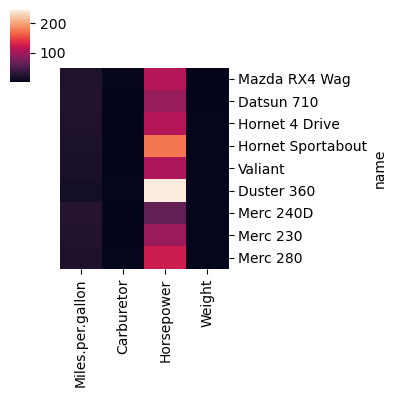

In [4]:
import seaborn as sns
g = sns.clustermap(mat, row_cluster= False, col_cluster= False, figsize=(4,4))

Strikingly, the horsepower variable saturates the color scale because horsepower lives in a different scale than the other variables. Consequently, we barely see variations in the other variables.

-----

### Centering And Scaling Variables

Bringing variables to a common scale is useful for visualization but also for computational and numerical reasons. Moreover, it makes analysis independent of the units chosen. For instance the mtcars dataset provide car weights in 1,000 pounds and gas consumption in miles per gallon. We would certainly want our analysis to be the same if these variables were expressed with the metric system.

The widely used operations to bring variables to a same scale are:

* `Centering`: Substracting the mean

* `Standard Scaling` or `Z-Score Normalization` : Centering then dividing by the standard deviation

These operations are implemented in the base `scikit-learn` function `StandardScaler()` and are often offered as parameters of other functions. 

Scaling is usually done for variables (data matrix columns). However, in some application contexts, row-scaling can be considered as well.

With `sns.clustermap` we can also scale the data by rows or columns by setting the argument `z_score` accordingly. We do it here in the classical way, by column:

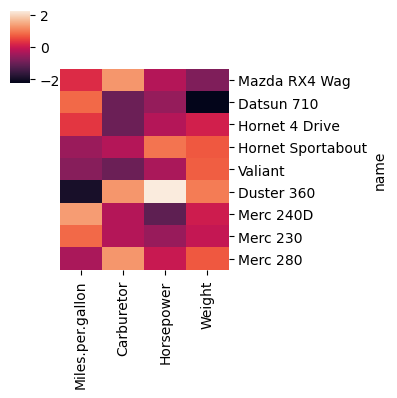

In [5]:
sns.clustermap(mat, row_cluster= False, col_cluster= False, z_score= 1, figsize= (4,4))

Scaling allows us to appreciate the variation for all variables. The default color scale is centered on 0. Because each column is centered, we find positive (red-ish) and negative (blue-ish) values in each column.

----

----

## Clustering 

While all data are rendered in the Figure 5.1, it is hard to see a pattern emerging. 

Which cars are similar to each others? Which variables are similar to each other? 

Clustering is the task of grouping observations by similarities. Clustering helps finding patterns in data matrices. 

Clustering can also be applied to variables, by simply applying clustering methods on the transpose of the data matrix.

There are several clustering algorithms. 

In the following sections, we explain two widely used clustering methods: `K-means` clustering and `hierarchical` clustering.

----

### K-Means Clustering

K-Means clustering aims to partition the observations into $K$ non-overlapping clusters. 
 
 The number of clusters $K$ is predefined. The clusters $C_1, C_2, ... , C_K$ define a partition of the observations, i.e., every observation belongs to one and only one cluster. 
 
 To this end, one makes use of so-called cluster centroids, denoted $\mu_1, \mu_2, ... , \mu_K$ and associates each observation to its closest centroid (Figure 5.2).

<img src = 'images/Yüksek Boyutlu Görselleştirmeler.png' width = 500>

Formally, one aims to determine the clusters $C_1, C_2, ..., C_K$
 and the centroids $\mu_1, \mu_2, ... , \mu_K$
 in order to minimize the within-cluster sum of squares:

$ 
\min_{C_1,\ldots,C_K,\;\mu_1,\ldots,\mu_K}
\sum_{k=1}^{K} \sum_{i \in C_k} \lVert x_i - \mu_k \rVert^2
$ ----->5.1

#### Algorithm

The minimization problem (Equation 5.1) is difficult because of the combinatorial number of partitions of $n$ observations into $K$ 
 clusters. However, two useful observations can be made.

##### First

First, if we assume that the positions of the $\mu_n$ are given, 

then each summand $\lVert x_i - \mu_k \rVert$ in Equation 5.1 can be minimized by including the observation $x_i$ to the cluster of its closest centroid. 

The number of clusters $K$ depends on the dataset.

##### Second

Second, if we now assume that the clusters are given, 

then the values of the centroids that minimize $\sum_{i \in C_k} \lVert x_i - \mu_k \rVert^2$ are the observation means, 

ie, $\mu_k = \frac{1}{|C_k|} \sum_{i \in C_k} x_i$. 

Hence, the centroids are the cluster means, giving the name of the algorithm.

These two observations lead to an iterative algorithm that provides in practice good solutions, <b>even though it does not guarantee to find the optimal solution.</b>

<img src = 'images/Yüksek Boyutlu Görselleştirmeler (1).png' width = 500>

-----

##### K-Means In Application

1- Choose the $K$ initial centroids (one for each cluster). Different methods such as sampling random observations are available for this task.

2- Assign each observation $x_i$ to its nearest centroid by computing the Euclidean distance between each observation to each centroid.

3- Update the centroids $\mu_k$ by taking the mean value of all of the observations assigned to each previous centroid.

4- Repeat steps 2 and 3 until the difference between new and former centroids is less than a previously defined threshold.

At every iteration, and at every step 2 and 3, the within-cluster sum of squares (Equation 5.1) decreases.

However, there is no guarantee to reach the optimal solution. 

In particular, the final clustering depends on the initialization (step 1). 

To not overly depend on the initialization, the K-means algorithm is typically executed with different random initializations. The clustering with lowest within-cluster sum of squares is then retained.

-----

##### Drawbacks 

* The number of clusters $K$ is properly selected

* The clusters are isotropically distributed, i.e., in each cluster the variables are not correlated and have equal variance

* The clusters have equal (or similar) variance

* The clusters are of similar size

<img src = 'images/Yüksek Boyutlu Görselleştirmeler (2).png' width = 700>

##### In Python

Let us now apply K-means to the mat data matrix searching for 2 clusters. 

This can be easily achieved with the `scikit-learn` function `KMeans()`. 

While not necessary, it is a good idea to scale the variables, in order not to give the variables with larger scales too much importance (by dominating the Euclidean distances). 

Another way to look at it, is that the scaling reduces to some extent the problem of anisotropic clusters. 

In the following code, we first scale the data matrix with `StandardScaler()`. We also use the argument `n_init` of `KMeans()` to perform multiple random initializations.

In [6]:
import sklearn

scaler = sklearn.preprocessing.StandardScaler()
X = pd.DataFrame(scaler.fit_transform(mat), index = mat.index, columns= mat.columns)

k = 2
clust_km = sklearn.cluster.KMeans(n_clusters= k, n_init= 20)
clust_km.fit(X)

clust_km.labels_

array([0, 0, 0, 1, 0, 1, 0, 0, 1], dtype=int32)

We now update our heatmap with the results of the clustering.

 We make use of the `row_colors` argument of `sns.clustermap()` which generates color-coded row annotations on the left side of the heatmap. 
 
 We furthermore order the rows of the data matrix by cluster.



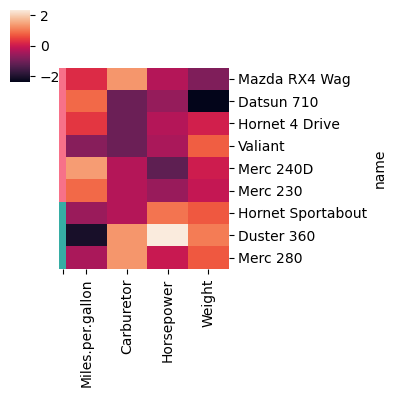

In [7]:
row_ann = pd.Series(['C' + str(s) for s in clust_km.labels_], index = mat.index)

unique_categories = np.unique(row_ann)

palette = sns.color_palette('husl', len(unique_categories))
color_maping = dict(zip(unique_categories, palette))

row_col = row_ann.map(color_maping)
sns.clustermap(X.iloc[np.argsort(row_ann)], row_colors= row_col, row_cluster= False, col_cluster= False, figsize=(4,4))

Cluster $C_1$ appears to group the heavy, powerful and gas-consuming cars and 

cluster $C_2$ the light, less powerful and more economic cars.

## Hierarchical Clustering

A major limitation of the K-means algorithm is that it relies on a <b>predefined number of clusters</b>.

What if the interesting number of clusters is larger or smaller? 

Hierarchical clustering allows exploring multiple levels of clustering granularity at once by computing nested clusters. It results in a tree-based representation of the observations, called a dendrogram. Below image shows an example of a hierarchical clustering using two variables only.



<img src = 'images/Yüksek Boyutlu Görselleştirmeler (3).png' width = 400>

Unlike with K-means, there is no objective function associated with hierarchical clustering. Hierarchical clustering is simply defined by how it operates.



We describe bottom-up (a.k.a. `agglomerative` ) hierarchical clustering:

1. Initialization: Compute all the $\frac{n(n-1)}{2}$ pairwise dissimilarities between the $n$
 observations. Treat each observation as its own cluster. A typically dissimilarity measure is the Euclidean distance. Other dissimilarities can be used (1-correlation), Manhattan distance, etc.

2. For $i = n, n-1, ... , 2:$
*  Fuse the two clusters that are least dissimilar. The dissimilarity between these two clusters indicates the height in the dendrogram at which the fusion should be placed.

* Compute the new pairwise inter-cluster dissimilarities among the $i-1$ remaining clusters using the linkage rule.



The `linkage rules` define dissimilarity between clusters. Here are four popular linkage rules:

* `Complete` : The dissimilarity between cluster A and cluster B is the largest dissimilarity between any element of A and any element of B. 

    $\max_{a \in A,\; b \in B} d(a,b)$

* `Single`: The dissimilarity between cluster A and cluster B is the smallest dissimilarity between any element of A and any element of B. <u>Single linkage can result in extended, trailing clusters in which single observations are fused one-at-a-time.</u>

    $\min_{a \in A,\; b \in B} d(a,b)$

* `Average`: The dissimilarity between cluster A and cluster B is the average dissimilarity between any element of A and any element of B.

    $\frac{1}{|A|\,|B|}\sum_{a \in A} \sum_{b \in B} d(a,b)$

* `Centroid`: The dissimilarity between cluster A and cluster B is the dissimilarity between the centroids (mean vector) of A and B. Centroid linkage can result in undesirable inversions.

    $\lVert \mu_A - \mu_B \rVert$


----------

### In Python

In Python, Hierarchical clustering can be performed using either the 

`AgglomerativeClustering` class from <u>scikit-learn</u>, 
or the `linkage` function from <u>scipy</u>. 

In both cases, the clustering entails two steps. First, it computes the distance between observations (rows of a DataFrame) across variables (columns of a DataFrame). Here, the Euclidean distance between rows is computed by default. Alternatives include the Manhattan or Minkowski distance. As for K-means, <u>it is recommended to work on scaled variables to not give too much importance to variables with large variance.</u> We therefore compute the pairwise Euclidean distance to our scaled data matrix X. 

Second, we use the resulting Euclidean distance matrix as a dissimilarity matrix to perform Hierarchical clustering. 

The default linkage method is <u>single</u> for linkage, 

and <u>ward</u> for Agglomerative Clustering. Here we use average.

In [8]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

hc_scipy = linkage(X, method= 'average')

hc_sklearn = sklearn.cluster.AgglomerativeClustering(linkage='average').fit_predict(X)

The results of hierarchical clustering can be shown using a `dendrogram` (i.e., a tree representation). Here, observations that are determined to be similar by the clustering algorithm are displayed close to each other in the `x`-axis.

The height in the dendrogram at which two clusters are merged represents the distance between those two clusters.

{'icoord': [[25.0, 25.0, 35.0, 35.0], [55.0, 55.0, 65.0, 65.0], [45.0, 45.0, 60.0, 60.0], [75.0, 75.0, 85.0, 85.0], [52.5, 52.5, 80.0, 80.0], [30.0, 30.0, 66.25, 66.25], [15.0, 15.0, 48.125, 48.125], [5.0, 5.0, 31.5625, 31.5625]], 'dcoord': [[0.0, np.float64(1.686236409517311), np.float64(1.686236409517311), 0.0], [0.0, np.float64(0.8551281831143587), np.float64(0.8551281831143587), 0.0], [0.0, np.float64(1.3039349663134179), np.float64(1.3039349663134179), np.float64(0.8551281831143587)], [0.0, np.float64(1.5981431443987575), np.float64(1.5981431443987575), 0.0], [np.float64(1.3039349663134179), np.float64(2.1765166664822457), np.float64(2.1765166664822457), np.float64(1.5981431443987575)], [np.float64(1.686236409517311), np.float64(2.457718283406245), np.float64(2.457718283406245), np.float64(2.1765166664822457)], [0.0, np.float64(3.140614226663734), np.float64(3.140614226663734), np.float64(2.457718283406245)], [0.0, np.float64(4.212933000617484), np.float64(4.212933000617484), np.f

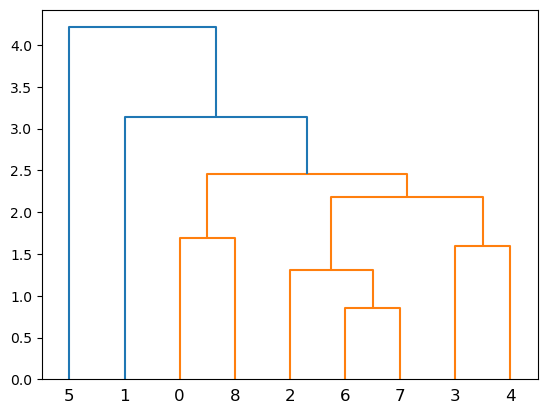

In [9]:
print(dendrogram(hc_scipy))

### Clustermaps including hierarchical clustering

As illustrated before, the library `sns.clustermap` enables the easy creation of heatmaps.

In the previous example, we set the parameters <u>row_cluster</u> and <u>col_cluster</u> to False to avoid the default computation of hierarchical clustering. 

If we want to include hierarchical clustering, we can simply set these parameters to True or let Python consider its default values.

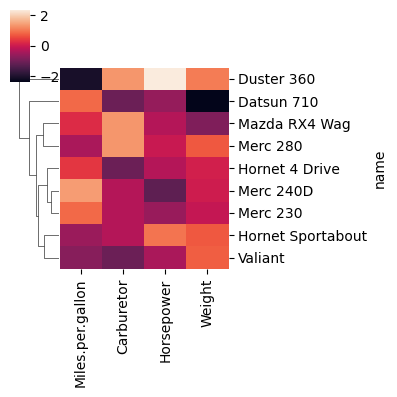

In [10]:
sns.clustermap(X, row_cluster= True, col_cluster= False, figsize=(4,4))

Compared to K-means (Figure 5.5), the hierarchical clustering shows useful different degrees of granularity of the clusters. We see the most similar cars grouping together (the Mercedes 230 and the Mercedes 240D). At the high level, the Duster 360 stands out as an outlier.

### Cutting Tree

After having inspected the result of a hierarchical clustering, it is often interesting to define distinct clusters by cutting the dendrogram at a certain height.

Typically, one cuts dendrogram either at a given height, or in order to obtain a certain number of clusters.

The functions `fcluster` from <u>scipy</u> and `AgglomerativeClustering` from <u>scikit-learn</u> support both options. Here is an example of cutting the dendrogram to get 3 clusters.

In [11]:
hc_sklearn = sklearn.cluster.AgglomerativeClustering(n_clusters=3, linkage = 'average').fit(X)

hc_sklearn.labels_

array([0, 2, 0, 0, 0, 1, 0, 0, 0])

In [12]:
fcluster(hc_scipy, t = 3, criterion='maxclust')

array([1, 2, 1, 1, 1, 3, 1, 1, 1], dtype=int32)

------

## Difference K-Means & Hierarchical

Both K-means and hierarchical clustering are well established and widely used. Here, we briefly state a few differences that may be considered when deciding which algorithm to apply in practice.

<u>The time complexity of K-Means clustering is linear</u>, 

while that of <u>hierarchical clustering is quadratic.</u> 

This implies that hierarchical clustering can not handle extremely large datasets as efficiently as K-Means clustering.

<u>In K-Means clustering, we start with a random choice of centroids for each cluster. Hence, the results produced by the algorithm depend on the initialization. Therefore, the results might differ when running the algorithm multiple times. Hierarchical clustering outputs reproducible results.</u>

<u>Another difference is that K-Means clustering requires the number of clusters a priori. In contrast, the number of clusters we find appropriate in hierarchical clustering can be decided a posteriori by interpreting the dendrogram.</u>

----

## Comparing clusterings with the Rand index

Let us first visualize the outcome of K-means and of the hierarchical clustering cut for 3 clusters thanks to the <u>row annotation option of sns.clustermap</u>.

In [13]:
row_ann = pd.DataFrame({'kmeans':['C'+str(s) for s in clust_km.labels_],
                        'hmeans':['C'+str(s) for s in hc_sklearn.labels_]}, index = X.index)
row_ann

,kmeans,hmeans
name,,
Mazda RX4 Wag,C0,C0
Datsun 710,C0,C2
Hornet 4 Drive,C0,C0
Hornet Sportabout,C1,C0
Valiant,C0,C0
Duster 360,C1,C1
Merc 240D,C0,C0
Merc 230,C0,C0
Merc 280,C1,C0


In [14]:
print(row_ann.values)

unique_categories = np.unique(row_ann.values)

print('Unique Categories: {}'.format(unique_categories))

[['C0' 'C0']
 ['C0' 'C2']
 ['C0' 'C0']
 ['C1' 'C0']
 ['C0' 'C0']
 ['C1' 'C1']
 ['C0' 'C0']
 ['C0' 'C0']
 ['C1' 'C0']]
Unique Categories: ['C0' 'C1' 'C2']


In [15]:
palette = sns.color_palette('husl', len(unique_categories))
palette

[(0.9677975592919913, 0.44127456009157356, 0.5358103155058701),
 (0.3126890019504329, 0.6928754610296064, 0.1923704830330379),
 (0.23299120924703914, 0.639586552066035, 0.9260706093977744)]

In [16]:
color_maping = dict(zip(unique_categories, palette))
row_col = row_ann.map(lambda x: color_maping[x])

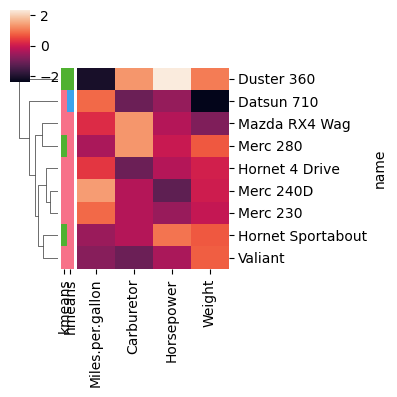

In [17]:
sns.clustermap(X, row_colors= row_col, col_cluster= False, figsize=(4,4))

-------

Comparing clustering results is a challenging task. When clustering into two groups, we could use evaluation measures from classification, which we will introduce later. Moving from two partitions of the data into arbitrarily many groups requires new ideas.

## Rand Index

The Rand index is a measure of the similarity between two partitions. Formally, we introduce the following definitions:

* $S = \{o_1, ..., o_n\}$ is a set of $n$ elements ($n$ observations)

* First partition $X = \{X_1, ..., X_k\}$ of $S$ into $k$ sets

* Second partition $Y = \{Y_1, ..., Y_l\}$ of $S$ into $l$ sets 

* $a$ a number of <b>pairs</b> of elements of $S$ that are <b>in the same set</b> in $X$ and in $Y$

* $b$ a number of <b>pairs</b> of elements of $S$ that are <b>in different sets</b> in $X$ and in $Y$

* $\binom{n}{2}$ total numbers of pairs of elements in $S$

Then, the Rand index can be computed as

$R = \frac{a+b}{\binom{n}{2}}$

### Properties of Rand Index

By definition, the Rand index has values between 0 and 1, including them.

A Rand index of 1 means that all pairs that are in the same cluster in the partition $X$
are also in the same cluster in the partition $Y$
and all pairs that are not in the same cluster in $X$
are also not in the same cluster in $Y$
.

Hence, the two partitions are identical with a Rand index of 1. In general, the higher the Rand index, the more similar are both partitions.

### Application of Rand Index

We can compute the Rand index between our k-means result and the cut of the hierarchical clustering for a given number of groups. 

-----

## PCA
Principal Component Analysis

### 2D -> 1D

To get an intuition of PCA, let us consider reducing a 2-dimensional dataset into a single dimension. This application has no visualization purposes but could help defining a linear combination of two variables into a aggregated score. For example, one can want to summarize the weight and horsepower of the cars into a single score.



Geometrically, we search for a line lying as close as possible to the data, in the sense of least squared Euclidean distances.

<img src = 'images/Yüksek Boyutlu Görselleştirmeler (4).png' width = 400>

<u>We will assume all variables to be centered and admit the line passes therefore through the origin.</u>

Let us denote $w$ a direction vector of the line of length $1$.

The closest point of the observation vector $x_i$ to the line is its orthogonal projection $p_T(x_i)$
which is equal to the scalar product of the direction vector and the observation vector, times the direction vector:

$p_T(x_i) = (w^T x_i) w$

Hence, we look for $w$ such that:

$\min_{\mathbf{w}} \sum_{i=1}^{n} \left\lVert \mathbf{x}_i - (\mathbf{w}^\top \mathbf{x}_i)\,\mathbf{w} \right\rVert^2
\quad \text{subject to} \quad \lVert \mathbf{w} \rVert = 1$

There is typically a unique solution to this optimization problem (up to a sign). This direction vector $w$ is called the first principal component (`PC1`) of the data.



#### PC1 Maximize Var

PC1 maximizes the variance of the projected data

We defined PC1 with a minimization problem. One can also see it as a maximization problem.

To this end, consider the orthogonal triangle defined by an observation vector $x_i$

its projection $p_T(x_i), and the origin. Pythagoras’ theorem implies that:

$||x_i||^2 = ||p_T(x_i)||^2 + ||x_i - p_T(x_i)||^2$

Over the entire dataset, the sum of the $||x_i||^2$ is constant independently of the choice of $w$.

Therefore minimization problem (Equation 5.2) is equivalent to:



$\max_{\mathbf{w}} \sum_{i=1}^{n} \left\lVert p_T(\mathbf{x}_i) \right\rVert^2
\quad \text{subject to} \quad \lVert \mathbf{w} \rVert = 1$


As we have centered the data, the origin is the mean of the data. Hence the sum of squared norms of the observation vectors is $n$ times their total variance.

<u>By linearity, the origin is also the mean of the projected data and thus:</u>

$\sum_{i=1}^{n} \left\lVert p_T(\mathbf{x}_i) \right\rVert^2
\;=\;
n\,\mathrm{Var}\!\bigl(p_T(X)\bigr)$

<u>Hence, one can equivalently consider that PC1 maximizes the variance of the projected data.</u>

<b>Result</b>: PC1 maximizes the variance of the projected data.

#### Proportion Variance:
 
The proportion of variance captured by PC1 is defined as the ratio of the variance of the projected data over the total variance of the data. It is a proportion, hence lies between 0 and 1. The higher it is, the smaller the sum of squared distances, the closer the line is to the data. The proportion of variance hence quantifies how good our dimension reduction is.

### Higher Dimension

In the general case, with $p$
 variables and $n$
 observations, one searches for the $q$-dimensional plane that is closest to the data in terms of sums of squared Euclidean distances. 
 
This is also the 
$q$-dimensional plane that maximizes the variance of the projected data.

An important property relates principal components to the `eigendecomposition of the covariance matrix`.

The covariance matrix is $\frac{1}{n}X^TX$

It is a symmetric positive matrix. We denote $w_1, ..., w_j,...$ its eigenvectors ordered by decreasing eigenvalues 
$\lambda_1 > ... > \lambda_j > ...$

<b>Result</b>: The PCA 
$q$-dimensional plane, i.e., the 
$q$-dimensional plane that is closest to the data in terms of sums of squared Euclidean distances, is the plane spanned by the first 
$q$ eigenvectors of the covariance matrix.

<b>Result</b>: The variance explained by the PCA 
$q$-dimensional plane equals to the sum of the 
 first $q$ eigenvalues of the covariance matrix.

These results have several implications:

1. The PCA planes are nested: the PCA 2D-plane contains PC1, the PCA 3D-plane contains the PCA 2D-plane, etc.

2. We call second principal component (PC2) the second eigenvector of the covariance matrix, etc.

3. The principal components are linearly uncorrelated. This is because the eigenvectors of a positive matrix are orthogonal to each other. If $n > p$
 (more observation than variables) the PCs form an orthonormal basis.

A 3D illustration of PCA is available at https://setosa.io/ev/principal-component-analysis/

-------

### In Python

PCA can be easily performed in Python by using the `scikit-learn` function `PCA()`

In most applications, scaling the data beforehand is important. Because PCA is based on minimizing squared Euclidean distances, scaling allows to not give too much importance to variables living on larger scales than the other ones. 

<u>Be careful</u>: PCA always centers data to 0, but it does <b><u>NOT</u></b> scale the variables to unit variance.



In the following examples, we perform `PCA` on our mat dataset. We run `StandardScaler` to scale the data before the PCA.

In [18]:
X = sklearn.preprocessing.StandardScaler().fit_transform(mat)
pca_res = sklearn.decomposition.PCA().fit(X)

The output can be stored in `pca_res`, which contains information about the values of each sample in terms of the principal components (pca.transform(X)), variance (pca.explained_variance_) of each principal component, and the relationship between the initial variables and the principal components (i.e. loadings, pca.components_).



An overview of the PCA result can be obtained from the object attributes. We remark that the cumulative proportion is always equal to one for the last principal component.

In [19]:
sum_df = pd.DataFrame({
    'Variance': pca_res.explained_variance_,
    'Proportion of Variance': pca_res.explained_variance_ratio_,
    'Cumulative Proportion': np.cumsum(pca_res.explained_variance_ratio_)
}, index=[f'PC{i+1}' for i in range(pca_res.n_components_)])
sum_df

,Variance,Proportion of Variance,Cumulative Proportion
PC1,3.003031,0.667340,0.667340
PC2,0.819505,0.182112,0.849453
PC3,0.574486,0.127664,0.977116
PC4,0.102977,0.022884,1.000000


In this example, the first principal component explains $66.7\%$ of the total variance and the second one $18.2\%$. So, just PC1 and PC2 can explain approximately $84.9\%$ of the total variance.

### Ploting PCA

#### Scree Plot

Plotting the results of PCA is particularly important. The so-called `scree plot` is a good first step for visualizing the PCA output, since it may be used as a diagnostic tool to check whether the PCA worked well on the selected dataset or not.

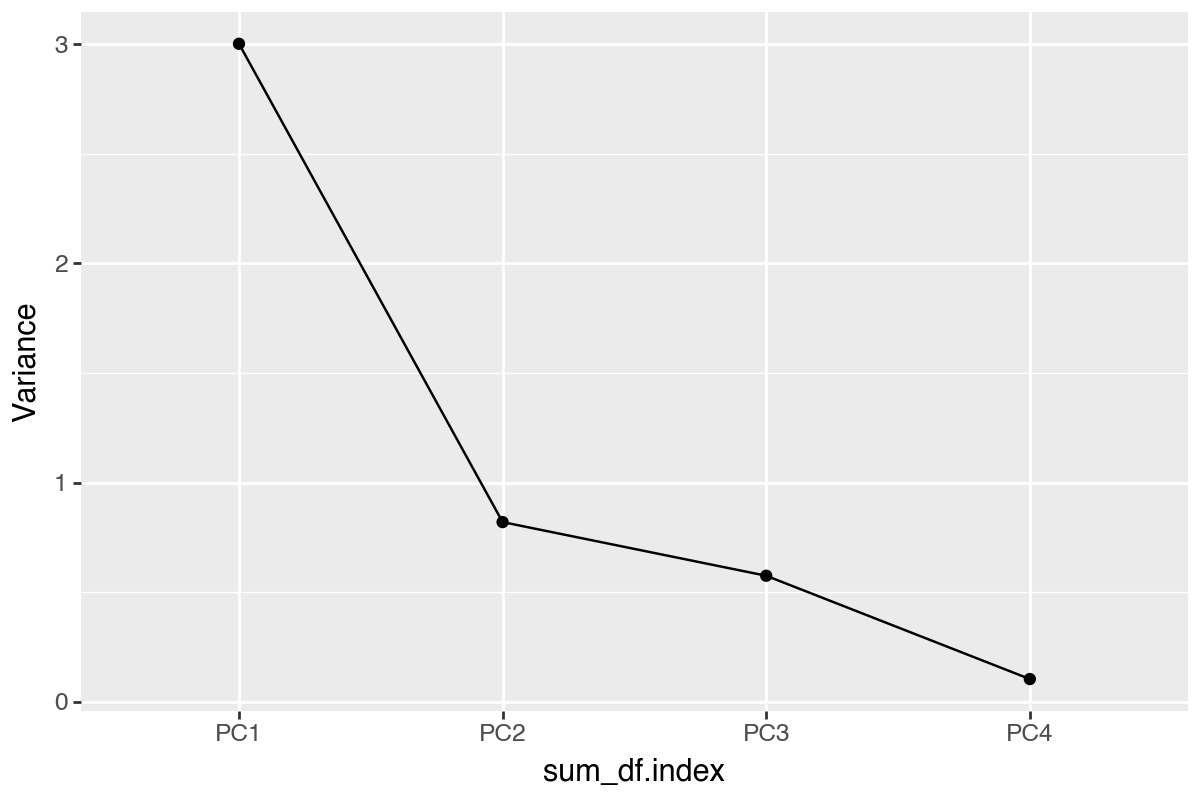

In [29]:
from plotnine import *

(
    ggplot(sum_df, aes('sum_df.index', 'Variance', group = 1)) +
    geom_line() +
    geom_point() +
    theme(figure_size=(6,4))
)

A variant of the scree plot can be considered by plotting the proportion of the total variance for every principal component.

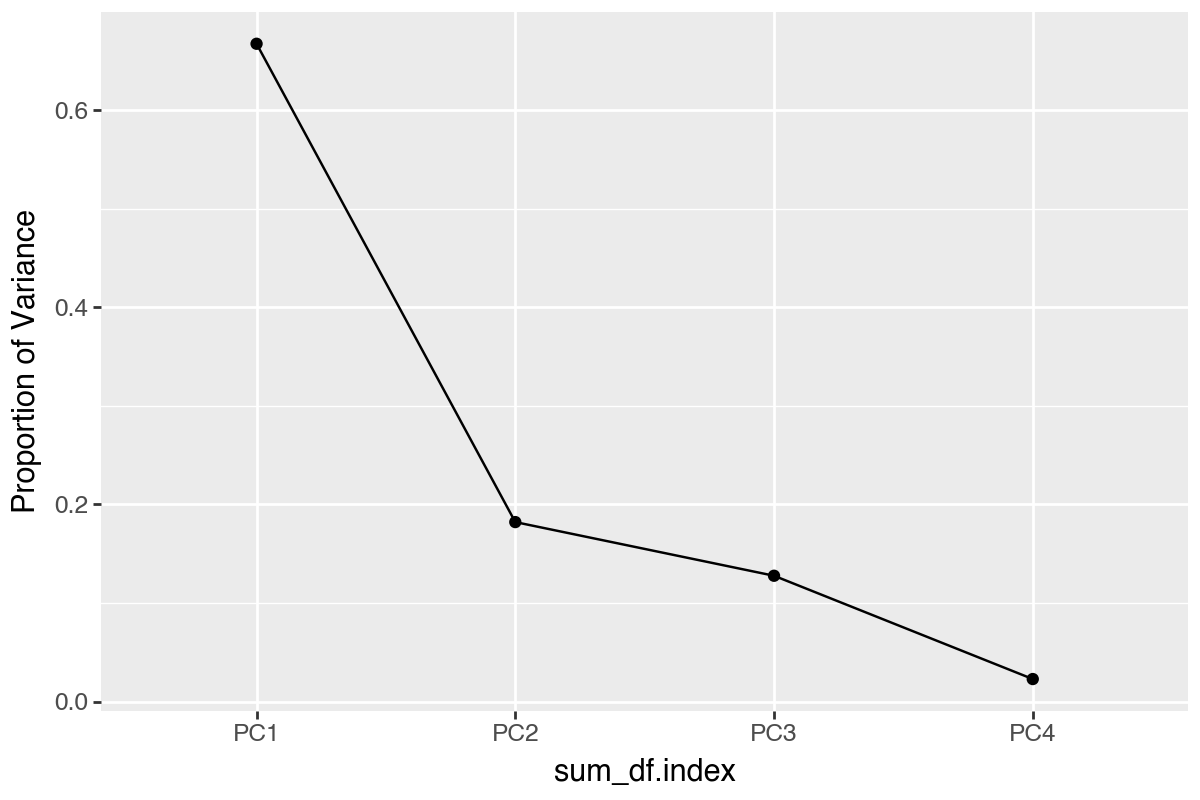

In [31]:
(
    ggplot(sum_df, aes('sum_df.index', 'Proportion of Variance', group = 1)) +
    geom_line() +
    geom_point() + 
    theme(figure_size= (6,4))
)

#### .transform()

We can access the projection of the original data on the principal components by using the method `.transform()`. 

A scatterplot shows the projection of the data on the first two principal components.

In [32]:
scores_df = pd.DataFrame(pca_res.transform(X),\
  columns = [f'PC{i+1}' for i in range(pca_res.n_components_)], \
    index=mat.index)


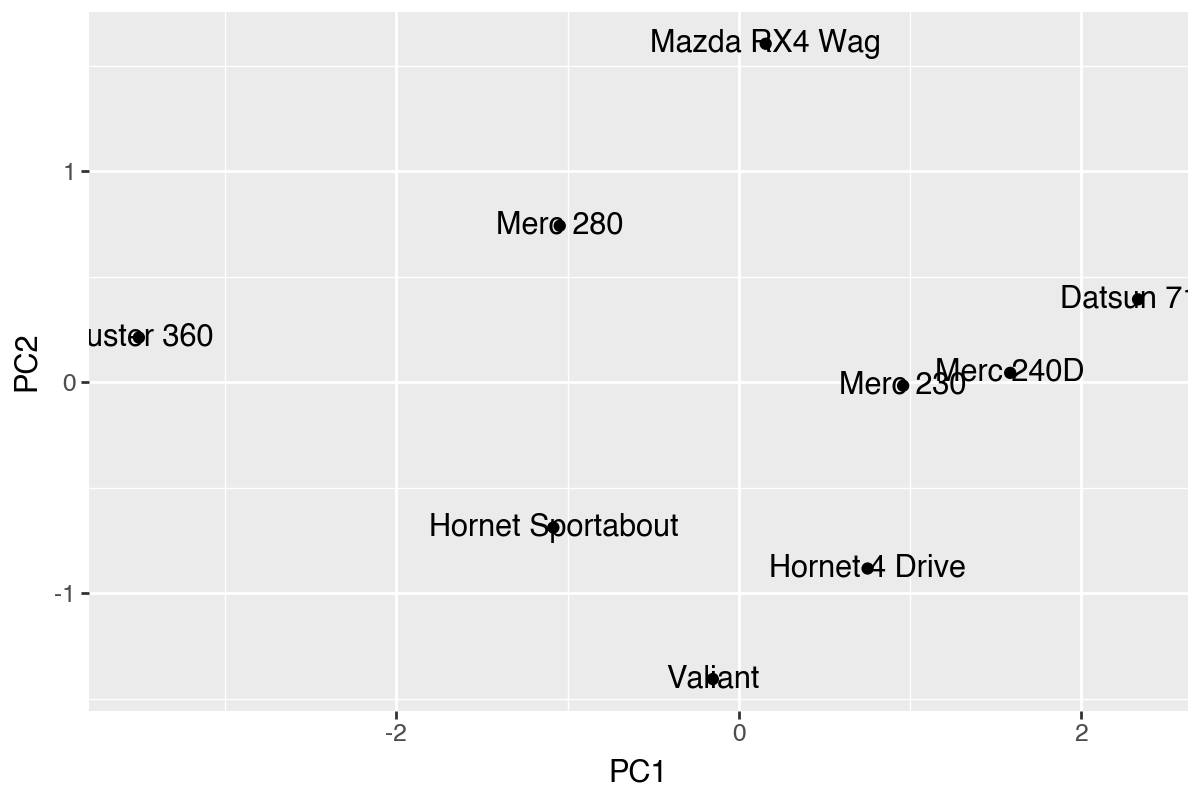

In [38]:
(
    ggplot(scores_df, aes('PC1', 'PC2')) +
    geom_point() + 
    geom_text(aes(label = 'scores_df.index')) +
    theme(figure_size= (6,4))
)